In [5]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = models.segmentation.deeplabv3_resnet50(weights="DEFAULT")

# change output to 1 class (optic disc)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
model.aux_classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

model = model.to(DEVICE)


In [6]:
import torch.optim as optim

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [7]:
TRAIN_IMG_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Training\Images"
TRAIN_MASK_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Training\GT"

# TEST DATASET PATHS
TEST_IMG_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Images"
TEST_MASK_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Test_GT" # Drishti often names the test mask folder 'Test_GT'

In [9]:

BATCH_SIZE = 4          # 4 is safe for 4GB VRAM
LEARNING_RATE = 1e-4
EPOCHS = 30
IMAGE_SIZE = 256   

In [10]:
class DrishtiDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        # Check if image directory exists
        if not os.path.exists(image_dir):
            raise FileNotFoundError(f"❌ Image Directory not found: {image_dir}")
        
        # --- FIX: Only check mask_dir if it is NOT None ---
        self.has_masks = False
        if mask_dir is not None:
            if not os.path.exists(mask_dir):
                raise FileNotFoundError(f"❌ Mask Directory not found: {mask_dir}")
            self.has_masks = True

        # --- AUTO-SCANNER for Images (Recursive) ---
        self.image_paths = []
        print(f"🔍 Scanning '{image_dir}' for images (recursive)...")
        for root, dirs, files in os.walk(image_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(root, file))
        print(f"✅ Found {len(self.image_paths)} images.")

        # --- AUTO-SCANNER for Masks (Recursive) ---
        self.mask_map = {}
        if self.has_masks:
            print(f"🔍 Scanning '{mask_dir}' for masks (recursive)...")
            for root, dirs, files in os.walk(mask_dir):
                for file in files:
                    if file.lower().endswith(('.png', '.jpg')):
                        # Map filename to its full absolute path
                        self.mask_map[file] = os.path.join(root, file)
            print(f"✅ Found {len(self.mask_map)} potential mask files.")
        else:
            print("⚠️ No mask directory provided. Running in Inference Mode (Images Only).")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        img_full_path = self.image_paths[index]
        img_name = os.path.basename(img_full_path)
        base_name = os.path.splitext(img_name)[0]
        
        # Strategy: Look for specific Drishti suffixes in our scanned map
        mask_path = None
        if self.has_masks:
            # Priority list of suffixes (Drishti uses these commonly)
            target_names = [
                f"{base_name}_ODsegSoftmap.png", 
                f"{base_name}_OD.png", 
                f"{base_name}.png"
            ]
            
            # Check exact matches
            for target in target_names:
                if target in self.mask_map:
                    mask_path = self.mask_map[target]
                    break
            
            # Fallback: Fuzzy search (if filename contains base_name and "OD")
            if mask_path is None:
                for key in self.mask_map:
                    if base_name in key and "OD" in key:
                        mask_path = self.mask_map[key]
                        break

        image = Image.open(img_full_path).convert("RGB")
        
        # Load Mask if found, else Black Mask
        mask = Image.new('L', image.size, 0)
        try:
            if mask_path:
                mask = Image.open(mask_path).convert("L") # Grayscale
        except:
            pass

        # Resize
        image = TF.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        mask = TF.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        
        # Normalize Image
        image = TF.normalize(image, [0.0, 0.0, 0.0], [1.0, 1.0, 1.0]) 
        
        # Threshold Mask (Drishti soft maps usually need > 0.1)
        mask[mask > 0.1] = 1.0
        mask[mask <= 0.1] = 0.0

        return image, mask

print("📂 Loading Datasets...")
try:
    print("--- Loading TRAIN Set ---")
    train_dataset = DrishtiDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MASK_DIR)
    
    print("--- Loading TEST Set ---")
    test_dataset = DrishtiDataset(image_dir=TEST_IMG_DIR, mask_dir=TEST_MASK_DIR)
    
    if len(train_dataset) == 0 or len(test_dataset) == 0:
        print(f"❌ ERROR: Zero images found! Please check your paths.")
    else:
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
        print(f"✅ Ready: {len(train_dataset)} Train images | {len(test_dataset)} Test images")

except Exception as e:
    print(f"❌ Dataset Error: {e}")

📂 Loading Datasets...
--- Loading TRAIN Set ---
🔍 Scanning 'E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Training\Images' for images (recursive)...
✅ Found 50 images.
🔍 Scanning 'E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Training\GT' for masks (recursive)...
✅ Found 100 potential mask files.
--- Loading TEST Set ---
🔍 Scanning 'E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Images' for images (recursive)...
✅ Found 51 images.
🔍 Scanning 'E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Test_GT' for masks (recursive)...
✅ Found 102 potential mask files.
✅ Ready: 50 Train images | 51 Test images


In [11]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = models.segmentation.deeplabv3_resnet50(weights="DEFAULT")

# change last layer for 1 output (optic disc)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
model.aux_classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

model = model.to(DEVICE)
print("Model ready")


Model ready


In [12]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [13]:
EPOCHS = 25

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(imgs)['out']
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss:.4f}")


Epoch 1/25 Loss: 7.8980
Epoch 2/25 Loss: 6.0104
Epoch 3/25 Loss: 4.5550
Epoch 4/25 Loss: 3.8687
Epoch 5/25 Loss: 3.4922
Epoch 6/25 Loss: 3.2178
Epoch 7/25 Loss: 2.9931
Epoch 8/25 Loss: 2.8064
Epoch 9/25 Loss: 2.6250
Epoch 10/25 Loss: 2.4764
Epoch 11/25 Loss: 2.3270
Epoch 12/25 Loss: 2.1888
Epoch 13/25 Loss: 2.0988
Epoch 14/25 Loss: 1.9670
Epoch 15/25 Loss: 1.8711
Epoch 16/25 Loss: 1.7823
Epoch 17/25 Loss: 1.7079
Epoch 18/25 Loss: 1.6209
Epoch 19/25 Loss: 1.5334
Epoch 20/25 Loss: 1.4698
Epoch 21/25 Loss: 1.3938
Epoch 22/25 Loss: 1.3305
Epoch 23/25 Loss: 1.2622
Epoch 24/25 Loss: 1.2030
Epoch 25/25 Loss: 1.1567


In [16]:
import torch
import torch.nn as nn
from torchvision import models

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = models.segmentation.deeplabv3_resnet50(weights=None)

# change final layer
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

# LOAD WEIGHTS (ignore aux mismatch)
state_dict = torch.load(
    r"E:\Glaucoma detection and segmentation\Glaucoma drishti\DeepLabV3_weights.pth",
    map_location=DEVICE
)

model.load_state_dict(state_dict, strict=False)

model = model.to(DEVICE)
model.eval()

print("✅ DeepLab model loaded successfully")


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24932\3827382104.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


✅ DeepLab model loaded successfully


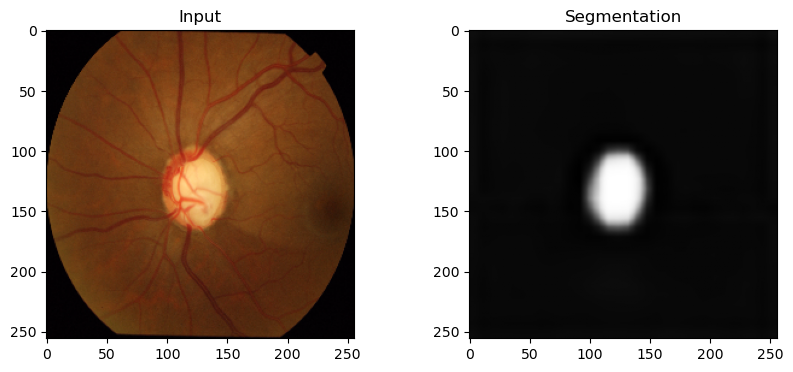

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = r"E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Images\glaucoma\drishtiGS_019.png"

image = cv2.imread(img_path)
image = cv2.resize(image,(256,256))
orig = image.copy()

image = image.astype(np.float32)/255.0
image = np.transpose(image,(2,0,1))
image = np.expand_dims(image,0)
image = torch.tensor(image).float().to(DEVICE)

with torch.no_grad():
    pred = model(image)['out']

mask = torch.sigmoid(pred)
mask = mask.squeeze().cpu().numpy()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(mask,cmap='gray')
plt.title("Segmentation")
plt.show()


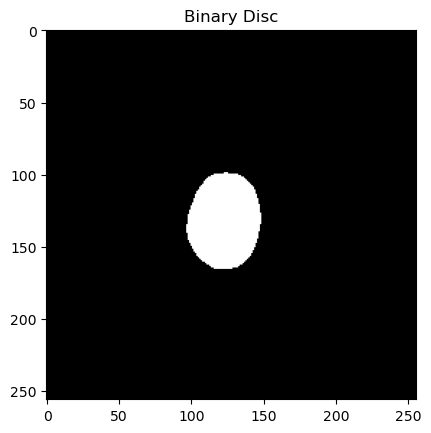

In [59]:
binary = (mask > 0.3).astype(np.uint8)

plt.imshow(binary,cmap='gray')
plt.title("Binary Disc")
plt.show()


In [60]:
disc_area = np.sum(binary==1)
print("Disc area:", disc_area)


Disc area: 2715


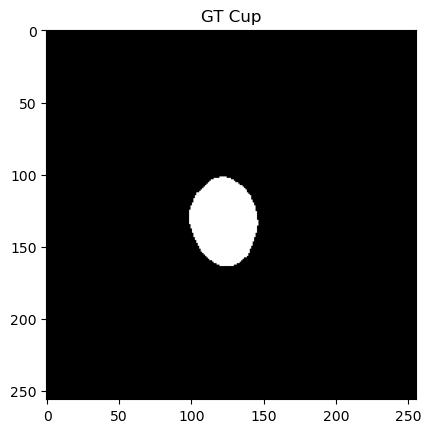

In [66]:
cup_path = r"E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Test_GT\drishtiGS_019\SoftMap\drishtiGS_019_cupsegSoftmap.png"

cup_gt = cv2.imread(cup_path,0)
cup_gt = cv2.resize(cup_gt,(256,256))

# convert softmap → binary
cup_gt = cup_gt/255.0
cup_gt = (cup_gt>0.1).astype(np.uint8)

plt.imshow(cup_gt,cmap='gray')
plt.title("GT Cup")
plt.show()






In [69]:
cup_area = np.sum(cup_gt==1)
print("Cup area:",cup_area)



Cup area: 2222


In [70]:
CDR = cup_area / disc_area
print("Calculated CDR:", CDR)


Calculated CDR: 0.8184162062615101


In [71]:
if CDR > 0.6:
    print("🟥 GLAUCOMA")
else:
    print("🟩 NORMAL")


🟥 GLAUCOMA


In [75]:
with open(r"E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Test_GT\drishtiGS_019\drishtiGS_019_cdrValues.txt") as f:
    values = f.read().strip().split()

# usually second value = average CDR
real_cdr = float(values[1])

print("Predicted CDR:", CDR)
print("Actual Avg CDR:", real_cdr)



Predicted CDR: 0.8184162062615101
Actual Avg CDR: 0.91
